In [1]:
import torch
import matplotlib.pyplot as plt

In [ ]:
import os
import pathlib
import pickle

path = pathlib.Path('/u/rfechner/out/entropy_logging/Qwen/Qwen2.5-1.5B_entropy_0.0_kl_0.0/entropy_dumps')
dumps = {}
for file in path.iterdir():
    if file.is_file() and file.name.endswith('.pickle'):
        step = file.name.split('-')[1].replace('.pickle', '')
        with open(file, 'rb') as io:
            dumps[str(step)] = pickle.load(io)
advs = [s['advantages'] for s in dumps.values()]
entropies = [s['deltas'] for s in dumps.values()]

### Advantage and entropy analysis

First of all, I'd like to plot the number of effective trajectories over time. An effective trajectory is
has non-zero advantage.

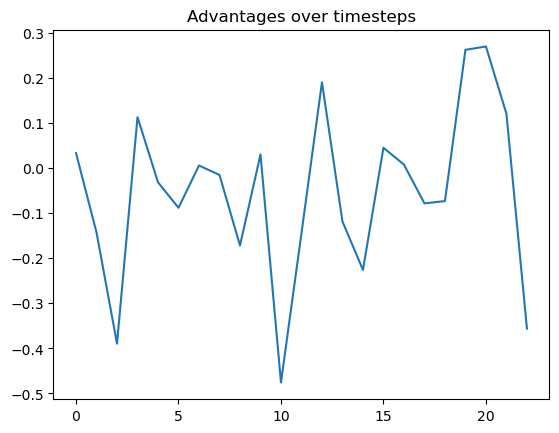

In [19]:
plt.plot([ad[ad != 0].mean() for ad in advs])
plt.title('Advantages over timesteps')
plt.show()

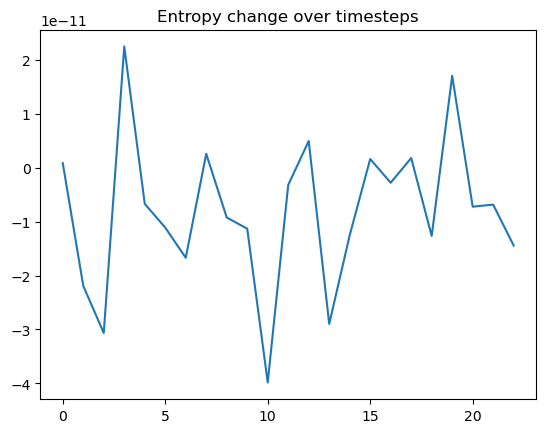

In [20]:
plt.plot([ent[ent != 0].mean() for ent in entropies])
plt.title('Entropy change over timesteps')
plt.show()

### Observation: mean change in entropy and mean advantage correlate

Shouldn't the reltationship be inversely proportional? When the advantage is high we should measure a decrease in entropy. Perhaps I've got a sign error?


{'deltas': array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 7.7376126e-12,  2.5536464e-11,  1.0102925e-11, ...,
         -1.7897892e-17, -2.9108703e-19, -1.5540282e-17],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
       shape=(128, 512), dtype=float32),
 'advantages': array([[ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [-0.499999, -0.499999, -0.499999, ..., -0.499999, -0.499999,
         -0.499999],
        [ 0.      ,  